# Dipping-target synthetic AEM inversion — paper figures

Loads recovered models and per-iteration inversion output, and builds:
- **Fig 1** — global OcTree mesh vs. a local (tiled) mesh with the volume-averaged model.
- **Fig 2** — model comparison (true / 1D / cold-start 3D / two-stage 3D), xz and xy.
- **Fig 3** — data fit on the y=0 line (observed vs predicted, per channel) for each result.
- **Fig 4** — convergence ($\phi_d$, $\phi_m$ vs iteration).
- **Fig 5** — forward-simulation cost (tiled vs global mesh).
- **Fig 6** — recovered overburden in plan view (shallow depth slice).

Conductivity is plotted with `Spectral_r` (resistors blue, conductors red);
air is NaN/white. Soundings are dots at the 30 m flight height.

In [24]:
%matplotlib inline
import os, glob, json
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import discretize
from simpeg import maps
from simpeg.electromagnetics import time_domain as tdem

CMAP = plt.get_cmap("Spectral_r").copy()
CMAP.set_bad("white")                    # air (NaN) -> white
plt.rcParams["figure.dpi"] = 110
RX = dict(marker="o", linestyle="none", ms=3.5, mfc="k", mec="w", mew=0.5)
NORM = LogNorm(vmin=6e-4, vmax=10)

## Geometry, true model, surveys

In [25]:
from _test_parametric import (
    build_global_mesh, build_true_model, build_local_meshes,
    rx_times, rx_y, sigma_back, sigma_target, target_z,
)

mesh = build_global_mesh()
active = mesh.cell_centers[:, 2] < 0
AIR = ~active
actmap = maps.InjectActiveCells(mesh, active, value_inactive=np.log(1e-8))
sigma_true = build_true_model(mesh)
n_t = len(rx_times)

rx_x_80 = (np.linspace(-500, 500, 26))[3:-3][::2]   # 3D survey: 10/line
rx_x_40 = (np.linspace(-500, 500, 26))[3:-3]        # 1D survey: 20/line
rz = 30.0
rx_locs_80 = discretize.utils.ndgrid([rx_x_80, rx_y, np.r_[rz]])
rx_locs_40 = discretize.utils.ndgrid([rx_x_40, rx_y, np.r_[rz]])

def sigma_full(m_active):
    s = np.asarray(maps.ExpMap() * actmap * m_active, dtype=float)
    s[AIR] = np.nan
    return s

sigma_true_plot = sigma_true.copy(); sigma_true_plot[AIR] = np.nan

Z_SLICE = float(np.mean(target_z))
IZ = int(round((Z_SLICE - mesh.origin[2]) / mesh.h[2][0]))
print(f"mesh {mesh.n_cells} cells ({int(active.sum())} active); "
      f"80m survey {rx_locs_80.shape[0]} stn, 40m survey {rx_locs_40.shape[0]} stn")

mesh 52340 cells (42284 active); 80m survey 50 stn, 40m survey 100 stn


## Load models and per-iteration output

In [26]:
def load_iters(folder):
    recs = [np.load(f, allow_pickle=True)["arr_0"].item()
            for f in sorted(glob.glob(os.path.join(folder, "*.npz")))]
    recs.sort(key=lambda o: o["iter"])
    return recs

iters_p1 = load_iters("_iters_phase1_ovbU5")            # parametric (Phase 1)
iters_p2 = load_iters("_iters_ovbU_5line")              # two-stage (Phase 2)
iters_cold = load_iters("_iters_coldstart_80m_superseded")
mrec_two = np.load("_mrec_ovbU5.npy")
mrec_cold = iters_cold[-1]["m"]
models_1d = np.load("_models_1d_40m.npy")               # (n_stn, n_layers) log-sigma
dobs_80 = np.load("_dobs_80m.npy")
dobs_40 = np.load("_dobs_40m.npy")

# 1D layered mesh (same as _test_1d_single, defined inline so we don't import
# that headless script -- its matplotlib.use("Agg") would disable inline figures)
_CS, _CORE, _NPAD, _PF = 25.0, 400.0, 12, 1.3
THICK = discretize.utils.unpack_widths([(_CS, int(np.ceil(_CORE/_CS))), (_CS, _NPAD, _PF)])
MESH1D = discretize.TensorMesh([np.r_[THICK, THICK[-1]]], origin="0")
# 1D layer-centre depths (for the 1D depth slice)
z1d_top = np.r_[0.0, -np.cumsum(THICK)]
z1d_cen = np.r_[(z1d_top[:-1] + z1d_top[1:]) / 2, z1d_top[-1] - THICK[-1] / 2]

def predict_1d(m_log_sigma, loc):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(loc, rx_times, orientation="z")
    src = tdem.sources.CircularLoop(receiver_list=[rx], location=loc, orientation="z",
                                    radius=10, waveform=tdem.sources.StepOffWaveform())
    sim = tdem.Simulation1DLayered(survey=tdem.Survey([src]), thicknesses=THICK,
                                   sigmaMap=maps.ExpMap(MESH1D))
    return sim.dpred(m_log_sigma)

print(f"iters: phase1 {len(iters_p1)}, phase2 {len(iters_p2)}, cold {len(iters_cold)}")

iters: phase1 4, phase2 9, cold 19


## Figure 1 — global mesh vs. local (tiled) mesh

(a) true model with the global OcTree mesh outlined; (b) the local mesh for a
source over the target, with the model **volume-averaged onto it** (`TileMap`)
— what the tiled forward actually solves on.

In [27]:
# local mesh for a central source over the target
loc_c = np.r_[20.0, 0.0, rz]
rx_c = tdem.receivers.PointMagneticFluxTimeDerivative(loc_c, rx_times, orientation="z")
src_c = tdem.sources.CircularLoop(receiver_list=[rx_c], location=loc_c, orientation="z",
                                  radius=10, waveform=tdem.sources.StepOffWaveform())
local_mesh = build_local_meshes(mesh, tdem.Survey([src_c]))[0]
tile = maps.TileMap(mesh, active, local_mesh)
local_actmap = maps.InjectActiveCells(local_mesh, active_cells=tile.local_active,
                                      value_inactive=np.log(1e-8))
m_local = tile * np.log(sigma_true[active])             # volume-averaged log-sigma
sig_local = np.asarray(maps.ExpMap() * local_actmap * m_local, dtype=float)
sig_local[local_mesh.cell_centers[:, 2] >= 0] = np.nan


print(f"global {mesh.n_cells} cells -> local {local_mesh.n_cells} cells")

global 52340 cells -> local 5510 cells


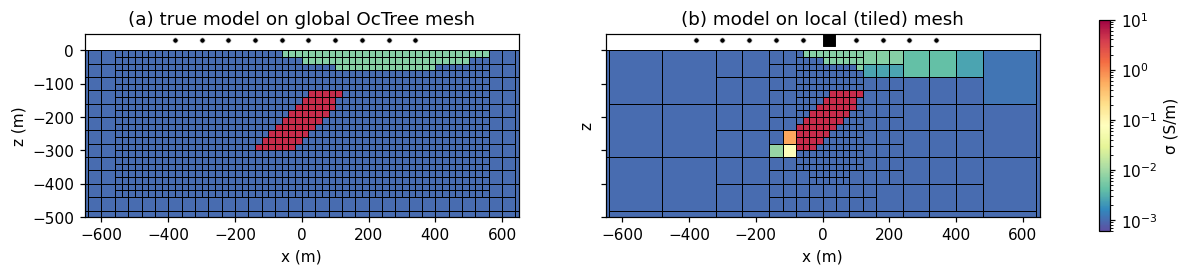

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharey=True)
gopts = dict(color="k", linewidth=0.5)

im = mesh.plot_slice(sigma_true_plot, normal="y", ax=axes[0],
                     pcolor_opts={"norm": NORM, "cmap": CMAP}, grid=True, grid_opts=gopts)[0]
axes[0].plot(rx_locs_80[:, 0], rx_locs_80[:, 2], **RX)
axes[0].set_title("(a) true model on global OcTree mesh")
local_mesh.plot_slice(sig_local, normal="y", ax=axes[1],
                      pcolor_opts={"norm": NORM, "cmap": CMAP}, grid=True,
                      grid_opts=gopts)
axes[1].plot(rx_locs_80[:, 0], rx_locs_80[:, 2], **RX)
axes[1].plot(loc_c[0], loc_c[2], marker="s", ms=8, mfc="k", mec="k", mew=0.6)
axes[1].set_title("(b) model on local (tiled) mesh")

axes[0].set_ylabel("z (m)")
for ax in axes:
    ax.set_xlim([-650, 650]); ax.set_ylim([-500, 50]); ax.set_aspect(1)
    ax.set_xlabel("x (m)");
fig.colorbar(im, ax=axes, shrink=0.5, label="\u03c3 (S/m)")
fig.savefig("fig1_meshes.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 2 — model comparison (true / 1D / cold-start 3D / two-stage 3D)

Top row: cross-sections at y=0. Bottom row: depth slices at z ≈ -210 m. Shared
conductivity scale (1e-3 to 10 S/m) so the columns are directly comparable.

In [38]:
NORM2 = LogNorm(vmin=1e-3, vmax=10)
nx40, ny = len(rx_x_40), len(rx_y)
iy0 = ny // 2
# 1D central-line section (xz) and depth slice (xy)
sec_1d = np.exp(models_1d[iy0 * nx40:(iy0 + 1) * nx40])          # (nx, nlay)
z1d_edges = np.r_[0.0, -np.cumsum(np.r_[THICK, THICK[-1]])]
dx = np.diff(rx_x_40).mean(); dy = np.diff(rx_y).mean()
x1d_edges = np.r_[rx_x_40 - dx/2, rx_x_40[-1] + dx/2]
y1d_edges = np.r_[rx_y - dy/2, rx_y[-1] + dy/2]
il = int(np.argmin(np.abs(z1d_cen - Z_SLICE)))                   # 1D layer ~ -210 m
slice_1d = np.exp(models_1d[:, il]).reshape(ny, nx40)           # (ny, nx)

def msh_xz(sig, ax):
    return mesh.plot_slice(sig, normal="y", ax=ax,
                           pcolor_opts={"norm": NORM, "cmap": CMAP})[0]
def msh_xy(sig, ax):
    return mesh.plot_slice(sig, normal="z", ind=IZ, ax=ax,
                           pcolor_opts={"norm": NORM, "cmap": CMAP})[0]



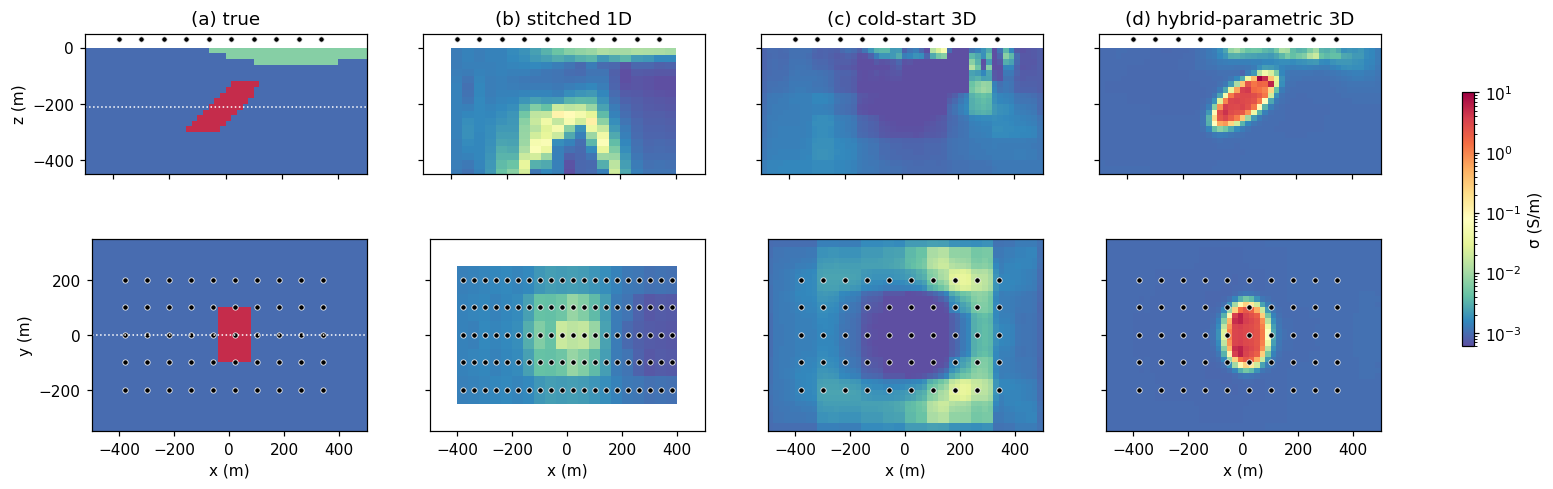

In [51]:
fig, ax = plt.subplots(2, 4, figsize=(19, 5), sharex=True)
cols = ["(a) true", "(b) stitched 1D", "(c) cold-start 3D", "(d) hybrid-parametric 3D"]

NORM = LogNorm(vmin=6e-4, vmax=10)

# --- top row: xz ---
im = msh_xz(sigma_true_plot, ax[0, 0])
ax[0, 1].pcolormesh(x1d_edges, z1d_edges, sec_1d.T, norm=NORM, cmap=CMAP)
msh_xz(sigma_full(mrec_cold), ax[0, 2]); msh_xz(sigma_full(mrec_two), ax[0, 3])
for j, c in enumerate(cols):
    ax[0, j].plot(rx_locs_80[:, 0], rx_locs_80[:, 2], **RX)
    ax[0, j].set_xlim([-500, 500]); ax[0, j].set_ylim([-450, 50]); ax[0, j].set_aspect(1)
    ax[0, j].set_title(f"{c}"); ax[0, j].set_xlabel("")
    if j > 0:
        ax[0, j].set_ylabel("")
        ax[0, j].set_yticklabels([])
ax[0, 0].set_ylabel("z (m)")
ax[0, 0].plot([-500, 500], [-210, -210], ":w", lw=1)
# --- bottom row: xy ---
msh_xy(sigma_true_plot, ax[1, 0])
ax[1, 1].pcolormesh(x1d_edges, y1d_edges, slice_1d, norm=NORM, cmap=CMAP)
msh_xy(sigma_full(mrec_cold), ax[1, 2]); msh_xy(sigma_full(mrec_two), ax[1, 3])
for j in range(4):
    locs = rx_locs_40 if j == 1 else rx_locs_80
    ax[1, j].plot(locs[:, 0], locs[:, 1], **RX)
    ax[1, j].set_xlim([-500, 500]); ax[1, j].set_ylim([-350, 350]); ax[1, j].set_aspect(1)
    ax[1, j].set_title(f""); ax[1, j].set_xlabel("x (m)")
    if j > 0:
        ax[1, j].set_ylabel("")
        ax[1, j].set_yticklabels([])
ax[1, 0].set_ylabel("y (m)")
ax[1, 0].plot([-500, 500], [0, 0], ":w", lw=1)
fig.colorbar(im, ax=ax, shrink=0.6, label="\u03c3 (S/m)")
fig.savefig("fig2_model_comparison.png", dpi=200, bbox_inches="tight")

## Figure 3 — data fit along the y=0 line

Observed (black) vs predicted (colour) for every sounding on the central line,
one curve per time channel (−dB/dt vs along-line position x). One panel per
result. Where predicted tracks observed the fit is good; the cold-start's
prediction departs from the data over the target.

In [52]:
iy0 = len(rx_y) // 2
nx80 = len(rx_x_80)
do80 = dobs_80.reshape(ny, nx80, n_t)[iy0]                       # (nx80, nt)
dp_two = iters_p2[-1]["dpred"].reshape(ny, nx80, n_t)[iy0]
dp_cold = iters_cold[-1]["dpred"].reshape(ny, nx80, n_t)[iy0]
do40 = dobs_40.reshape(ny, nx40, n_t)[iy0]                       # (nx40, nt)
# 1D predicted along the y=0 line (forward each recovered sounding)
dp_1d = np.array([predict_1d(models_1d[iy0 * nx40 + ix], rx_locs_40[iy0 * nx40 + ix])
                  for ix in range(nx40)])                        # (nx40, nt)



In [57]:
dob.shape

(10, 20)

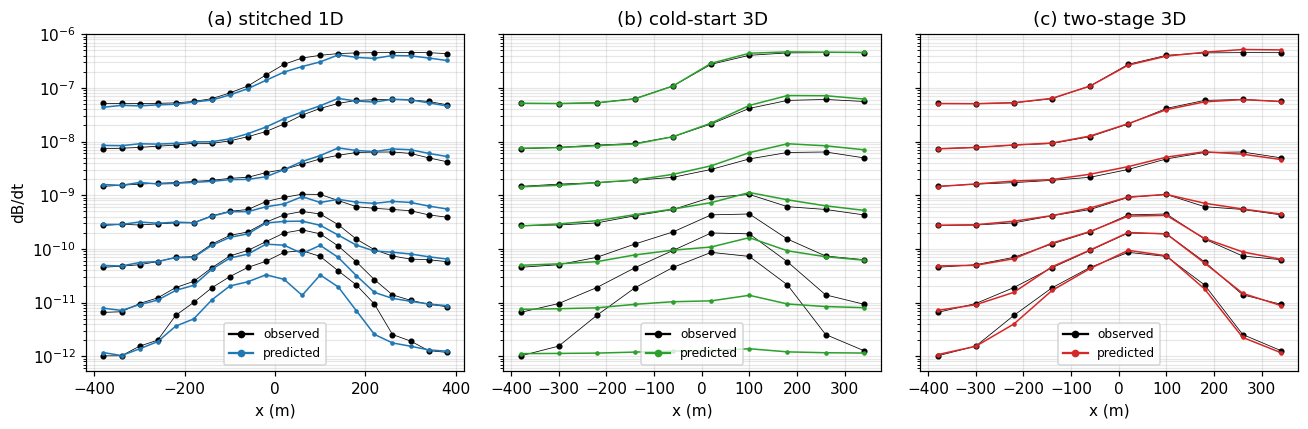

In [ ]:
from matplotlib.lines import Line2D
panels = [("(a) stitched 1D", rx_x_40, do40, dp_1d, "C0"),
          ("(b) cold-start 3D", rx_x_80, do80, dp_cold, "C2"),
          ("(c) two-stage 3D", rx_x_80, do80, dp_two, "C3")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for a, (ttl, xx, dob, dpr, col) in zip(ax, panels):
    a.semilogy(xx, -dob[:, 1::3], "-ok", ms=3, lw=0.5)
    a.semilogy(xx, -dpr[:, 1::3], "-o", color=col, mfc=col, ms=2, lw=1)
    a.set_title(ttl); a.set_xlabel("x (m)"); a.grid(True, alpha=0.3, which="both")
    a.legend([Line2D([0], [0], color="k", marker="o", ms=4),
              Line2D([0], [0], color=col, marker="o", ms=4)],
             ["observed", "predicted"], fontsize=8, loc="lower center")
ax[0].set_ylabel("db/dt")
# fig.suptitle("data fit on the y=0 line (one curve per time channel)", y=1.01)
fig.tight_layout()
fig.savefig("fig3_datafit_line.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 4 — convergence ($\phi_d$, $\phi_m$ vs iteration)

Data misfit $\phi_d/N$ (target = 1) and model norm $\phi_m$ for the cold-start
3D, the Phase-1 parametric, and the Phase-2 (two-stage) 3D inversions.

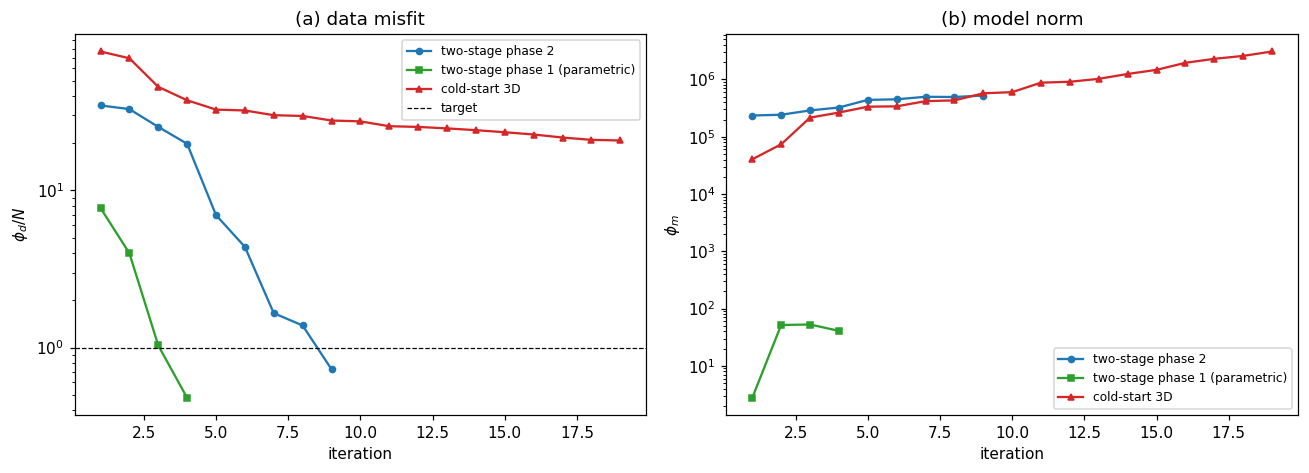

In [7]:
def conv(it): return (np.array([o["iter"] for o in it]),
                      np.array([o["phi_d"] for o in it]),
                      np.array([o["phi_m"] for o in it]))
n_full = rx_locs_80.shape[0] * n_t      # 1000
n_p1 = rx_locs_80.shape[0] * 5          # 250
runs = [("two-stage phase 2", iters_p2, n_full, "C0-o"),
        ("two-stage phase 1 (parametric)", iters_p1, n_p1, "C2-s"),
        ("cold-start 3D", iters_cold, n_full, "C3-^")]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for lab, it, nd, st in runs:
    i, pd, pm = conv(it)
    ax[0].semilogy(i, pd/nd, st, ms=4, label=lab)
    ax[1].semilogy(i, pm, st, ms=4, label=lab)
ax[0].axhline(1.0, color="k", ls="--", lw=0.8, label="target")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("$\phi_d / N$")
ax[0].set_title("(a) data misfit"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("$\phi_m$")
ax[1].set_title("(b) model norm"); ax[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig("fig4_convergence.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 5 — forward-simulation cost (single sounding)

Tiled local mesh vs. the full global mesh; only the `dpred` call is timed,
single-threaded. (From `_timing_{tiled,global}.json`.)

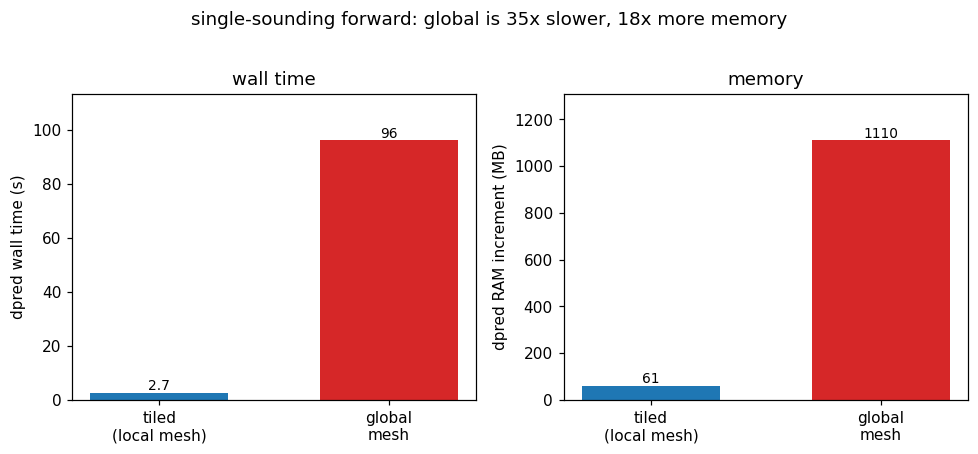

In [8]:
t = json.load(open("_timing_tiled.json")); g = json.load(open("_timing_global.json"))
labels = ["tiled\n(local mesh)", "global\nmesh"]
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, key, ylab, ttl in [
    (ax[0], "dpred_time_median_s", "dpred wall time (s)", "wall time"),
    (ax[1], "rss_dpred_increment_mb", "dpred RAM increment (MB)", "memory")]:
    vals = [t[key], g[key]]
    bars = a.bar(labels, vals, color=["C0", "C3"], width=0.6)
    for b, v in zip(bars, vals):
        a.text(b.get_x()+b.get_width()/2, v, f"{v:.0f}" if v >= 10 else f"{v:.1f}",
               ha="center", va="bottom", fontsize=9)
    a.set_ylabel(ylab); a.set_title(ttl)
    a.set_ylim(0, max(vals)*1.18)
fig.suptitle(f"single-sounding forward: global is {g['dpred_time_median_s']/t['dpred_time_median_s']:.0f}x "
             f"slower, {g['rss_dpred_increment_mb']/t['rss_dpred_increment_mb']:.0f}x more memory", y=1.02)
fig.tight_layout()
fig.savefig("fig5_forward_cost.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 6 — recovered overburden (plan view, shallow)

Depth slice at z ≈ -20 m: the two-stage 3D inversion resolves the laterally
variable conductive overburden basin (true vs recovered).

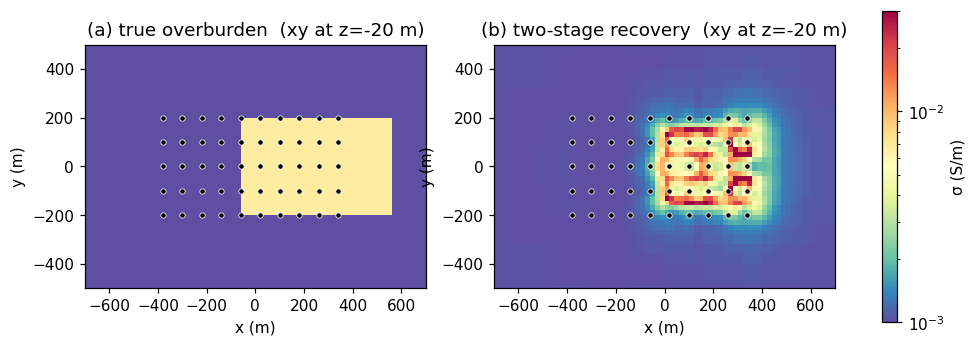

In [9]:
IZ_SHALLOW = int(round((-20.0 - mesh.origin[2]) / mesh.h[2][0]))
NORM_OVB = LogNorm(vmin=1e-3, vmax=3e-2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a, sig, ttl in [(ax[0], sigma_true_plot, "(a) true overburden"),
                    (ax[1], sigma_full(mrec_two), "(b) two-stage recovery")]:
    im = mesh.plot_slice(sig, normal="z", ind=IZ_SHALLOW, ax=a,
                         pcolor_opts={"norm": NORM_OVB, "cmap": CMAP})[0]
    a.plot(rx_locs_80[:, 0], rx_locs_80[:, 1], **RX)
    a.set_xlim([-700, 700]); a.set_ylim([-500, 500]); a.set_aspect(1)
    a.set_title(ttl + "  (xy at z=-20 m)"); a.set_xlabel("x (m)"); a.set_ylabel("y (m)")
fig.colorbar(im, ax=ax, shrink=0.8, label="\u03c3 (S/m)")
fig.savefig("fig6_overburden_planview.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 7 — copy of Fig 3 + the 1D model's 3D forward

Same as Fig 3 with a fourth panel (d): the stitched-1D model mapped onto the 3D mesh (nearest-sounding column, true background elsewhere) and forward-modelled with the tiled 3D code (`_test_1d_forward3d.py` -> `_dpred_1d_on_3d.npy`). Panel (a) is the 1D's own 1D-forward fit; (d) is that same model's true 3D response.

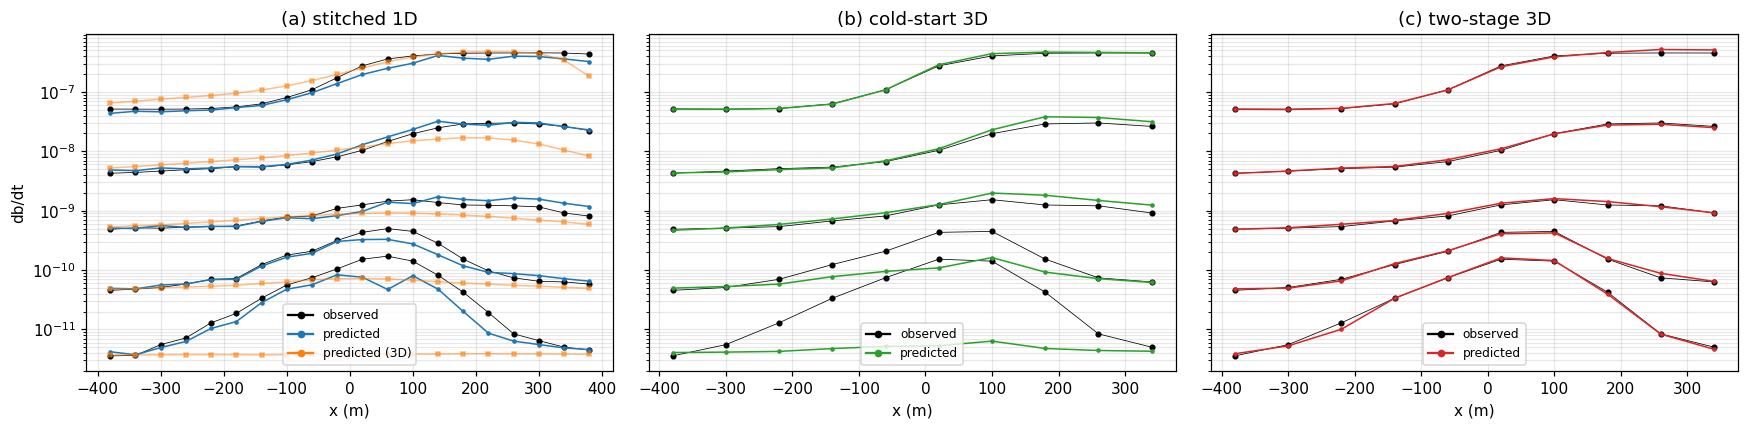

In [ ]:
from matplotlib.lines import Line2D
dp_1d3d = np.load("_dpred_1d_on_3d.npy").reshape(ny, nx40, n_t)[iy0]
panels = [("(a) stitched 1D", rx_x_40, do40, dp_1d, "C0"),
          ("(b) cold-start 3D", rx_x_80, do80, dp_cold, "C2"),
          ("(c) hybrid-parametric 3D", rx_x_80, do80, dp_two, "C3")]


data1d_3d = ("(d) 1D model, 3D forward", rx_x_40, do40, dp_1d3d, "C1")


fig, ax = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for a, (ttl, xx, dob, dpr, col) in zip(ax, panels):
    a.semilogy(xx, -dob[:, 1::4], "-ok", ms=3, lw=0.5)
    a.semilogy(xx, -dpr[:, 1::4], "-o", color=col, mfc=col, ms=2, lw=1)
    a.set_title(ttl); a.set_xlabel("x (m)"); a.grid(True, alpha=0.3, which="both")
    leg_colors = [Line2D([0], [0], color="k", marker="o", ms=4),
              Line2D([0], [0], color=col, marker="o", ms=4)]
    leg = ["observed", "predicted"]
    if a == ax[0]:
        a.semilogy(xx, -data1d_3d[3][:, 1::4], "-s", color=data1d_3d[-1], mfc=data1d_3d[-1], ms=2, lw=1, alpha=0.5)
        leg_colors += [Line2D([0], [0], color=data1d_3d[-1], marker="o", ms=4)]
        leg += ["predicted (3D)"]
    a.legend(leg_colors,
             leg, fontsize=8, loc="lower center")
ax[0].set_ylabel("db/dt")
fig.tight_layout()
fig.savefig("fig7_datafit_line_1d3d.png", dpi=200, bbox_inches="tight")
plt.show()